# Pattern extraction

In [8]:
import numpy as np
import pandas as pd
import scipy as sp
import  pickle
from scipy.fft import fft
from time import localtime, strftime
import matplotlib.pyplot as plt
from skimage.morphology import  disk,remove_small_objects
from skimage.filters.rank import gradient
from skimage.util import img_as_ubyte 
import wave
import os
import tqdm as tqdm

###########################
# Folder Name Setting
###########################

essential_folder = 'essential_data/'
supplemental_folder = 'supplemental_data/'
spectro_folder = 'spectrograms2/'
single_spectro_folder ='my_spectro_single/'
dp_folder = 'DP/'
subm_folder = 'Submission/'
log_folder = 'log/'
model_folder = 'models/'

# Each audio file has a unique recording identifier ("rec_id"), ranging from 0 to 644. 
# The file rec_id2filename.txt indicates which wav file is associated with each rec_id.
rec2f = pd.read_csv(essential_folder + 'rec_id2filename.txt', sep = ',')

# There are 19 bird species in the dataset. species_list.txt gives each a number from 0 to 18. 
species = pd.read_csv(essential_folder + 'species_list.txt', sep = ',')
num_species = 19

# The dataset is split into training and test sets. 
# CVfolds_2.txt gives the fold for each rec_id. 0 is the training set, and 1 is the test set.
cv =  pd.read_csv(essential_folder + 'CVfolds_2.txt', sep = ',')

# This is your main label training data. For each rec_id, a set of species is listed. The format is:
# rec_id,[labels]
raw =  pd.read_csv(essential_folder + 'rec_labels_test_hidden.txt', sep = ';')
label = np.zeros(len(raw)*num_species)
label = label.reshape([len(raw),num_species])
for i in range(len(raw)):
    line = raw.iloc[i]  # Use iloc[] instead of iloc()
    # Get the first column value and convert to string
    line_str = str(line.iloc[0]) if hasattr(line, 'iloc') else str(line[0])
    labels = line_str.split(',')
    labels.pop(0) # rec_id == i
    for c in labels:
        if(c != '?'):
            label[i,int(c)] = 1  # Convert c to int

label = pd.DataFrame(label)
label['rec_id'] = cv.rec_id
label['fold'] = cv.fold
label['filename'] = rec2f.filename



# Training Model (Machine Learning)

/tmp/ipykernel_1134295/1965743203.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pc'] = pc
/tmp/ipykernel_1134295/1965743203.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pc'] = pc
/home/crabbedfish/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_r

NEURAL NETWORK TRAINING FOR BIRD SPECIES CLASSIFICATION

Dataset shapes:
Training features: (322, 6079)
Training labels: (322, 19)
Test features: (323, 6079)

After train/validation split:
Training: (257, 6079), Validation: (65, 6079)

Dataset is ongebalanceerd.
Gewicht voor klasse 0 (geen vogel): 0.53
Gewicht voor klasse 1 (wel vogel): 8.78

MODEL ARCHITECTURE


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 512)            │     3,112,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 384)            │       196,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 320)            │       123,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 3,564,371 (13.60 MB)

...

Training:  38%|███▊      | 191/500 [02:21<03:36,  1.43it/s, loss=1.2071, val_loss=1.4008, auc=0.9791, val_auc=0.7341]


Epoch 192: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 192: val_auc did not improve from 0.74906


Training:  38%|███▊      | 192/500 [02:22<03:34,  1.44it/s, loss=1.2062, val_loss=1.3983, auc=0.9777, val_auc=0.7342]

Epoch 192: early stopping
Restoring model weights from the end of the best epoch: 177.


Training:  38%|███▊      | 192/500 [02:22<03:48,  1.35it/s, loss=1.2062, val_loss=1.3983, auc=0.9777, val_auc=0.7342]


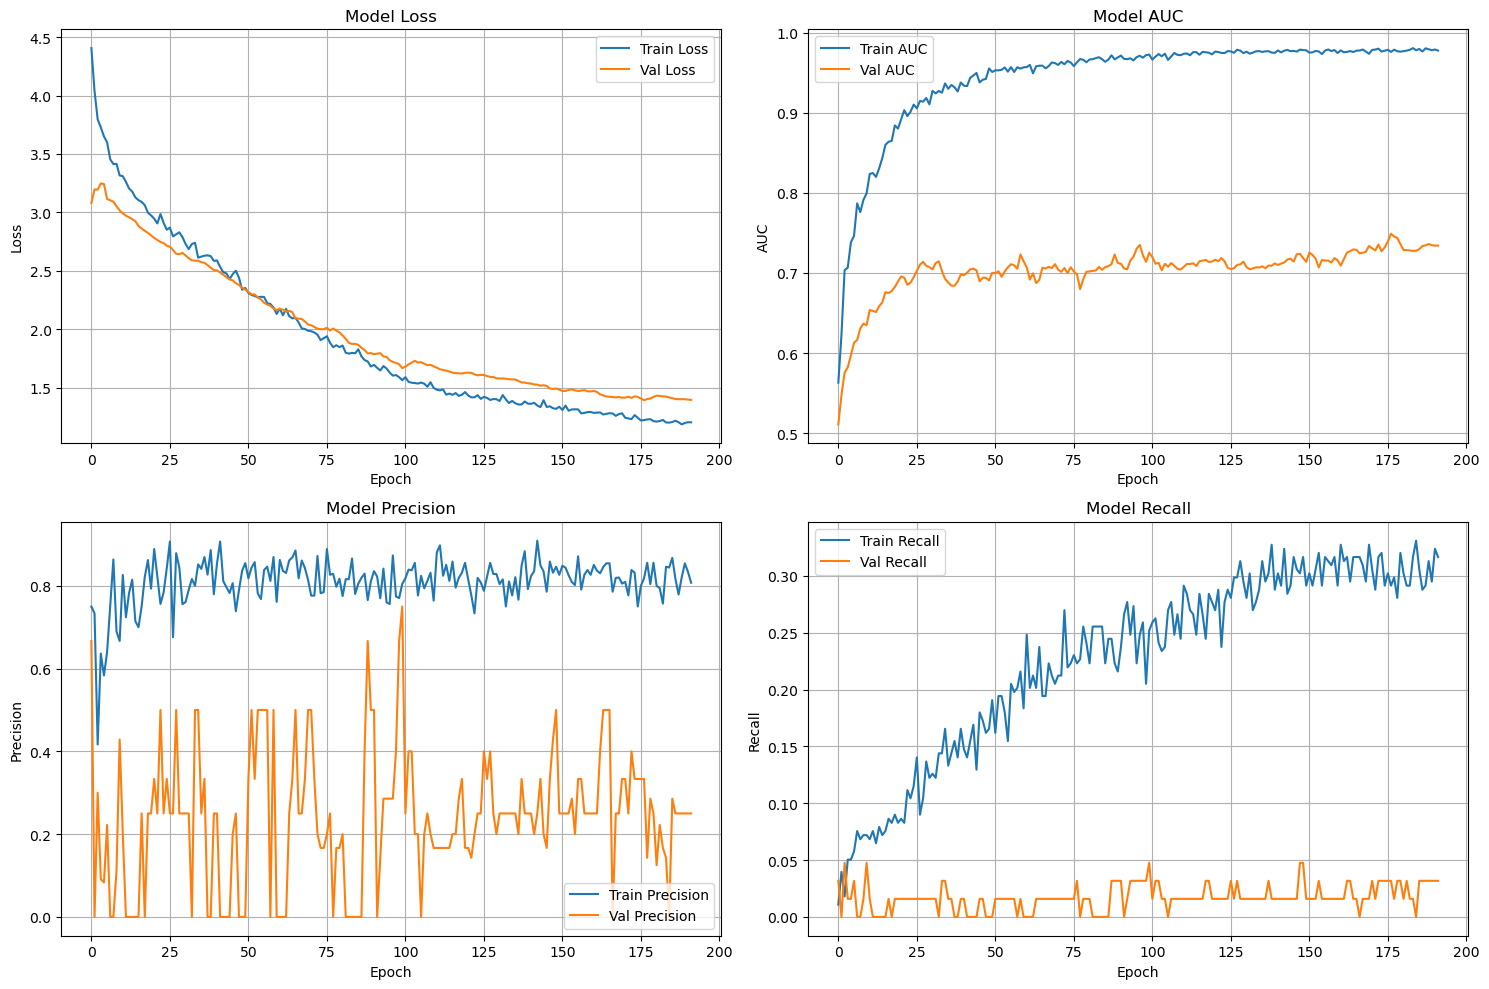


EVALUATION

Validation Results:
Loss: 1.3951
Accuracy: 0.1077
AUC: 0.7491
Precision: 0.3333
Recall: 0.0317

GENERATING PREDICTIONS
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Creating submission file...
Submission saved to: Submission/nn_bird_classification_auc0.7491.csv

TRAINING COMPLETE!
Best model saved to: models/best_bird_model.h5
Training history saved to: log/training_history.pkl
Submission file: Submission/nn_bird_classification_auc0.7491.csv


In [7]:
###################################################
# Additional imports for Neural Network
###################################################
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tqdm import tqdm



# Create folders if they don't exist
os.makedirs(dp_folder, exist_ok=True)
os.makedirs(subm_folder, exist_ok=True)
os.makedirs(log_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)

###################################################
## Load Essential Data (reuse from Cell 3)
## rec2f, species, num_species, cv, label are already defined
###################################################

# Visualize species distribution
spec_avg = label[label.fold ==0][range(num_species)].mean()

# Read histogram of segments features
hos = pd.read_csv(supplemental_folder + 'histogram_of_segments.txt', sep = ',',skiprows=1,header=0)
hos_features = ['hos_'+str(x) for x in range(100) ]
hos.columns = ['rec_id'] +hos_features

data = pd.merge(left = label, right = hos ,how = 'left', left_on = 'rec_id', right_on = 'rec_id')
data = data.fillna(0)

##############################
##          TRAIN           ##
##############################
train = data[data.fold==0]
pc = []
for i in range(len(train)):
    s = train.filename.iloc[i][:5]
    pc.append(int(s[2:s.find('_')]))  # PC1 - PC18

train['pc'] = pc

# Load spectral features
pkl_file = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'rb')
tr_spec = pickle.load(pkl_file)
pkl_file.close()
spec_names = ['tr_spec_'+str(x) for x in range(tr_spec.shape[1]) ]
Spec_Df = pd.DataFrame(tr_spec, columns = spec_names)
Spec_Df['rec_id'] = train.index
train2 = pd.merge(left = train, right = Spec_Df, left_index = True, right_on = 'rec_id')

# Load logarithmic spectral features
pkl_file = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
tr_log_spec = pickle.load(pkl_file)
pkl_file.close()
log_spec_names = ['tr_log_spec_'+str(x) for x in range(tr_log_spec.shape[1]) ]
Spec_Log_Df = pd.DataFrame(tr_log_spec, columns = log_spec_names)
Spec_Log_Df['rec_id'] = train.index

train3 = pd.merge(left = train2, right = Spec_Log_Df, left_on = 'rec_id', right_on = 'rec_id')

##############################
##          TEST            ##
##############################
test = data[data.fold==1]
pc = []
for i in range(len(test)):
    s = test.filename.iloc[i][:5]
    pc.append(int(s[2:s.find('_')]))  # PC1 - PC18

test['pc'] = pc

# Load test spectral features
pkl_file = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'rb')
test_spec = pickle.load(pkl_file)
pkl_file.close()
Test_Spec_Df = pd.DataFrame(test_spec, columns = spec_names)
Test_Spec_Df['rec_id'] = test.index
test2 = pd.merge(left = test, right = Test_Spec_Df, left_index = True, right_on = 'rec_id')

# Load test logarithmic features
pkl_file = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
test_log_spec = pickle.load(pkl_file)
pkl_file.close()
Test_Spec_Log_Df = pd.DataFrame(test_log_spec, columns = log_spec_names)
Test_Spec_Log_Df['rec_id'] = test.index

test3 = pd.merge(left = test2, right = Test_Spec_Log_Df, left_on = 'rec_id', right_on = 'rec_id')

#######################################################
## NEURAL NETWORK TRAINING                          ##
#######################################################

print("="*60)
print("NEURAL NETWORK TRAINING FOR BIRD SPECIES CLASSIFICATION")
print("="*60)

# Prepare features
feature_columns = spec_names + hos_features + ['pc'] + log_spec_names
X_train = train3[feature_columns].values
y_train = train3[range(num_species)].values
X_test = test3[feature_columns].values

print(f"\nDataset shapes:")
print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test features: {X_test.shape}")

# Feature scaling - important for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Split training data for validation
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"\nAfter train/validation split:")
print(f"Training: {X_train_nn.shape}, Validation: {X_val_nn.shape}")


# Tel alle '1'-en (positieven) in je hele training set
n_pos = np.sum(y_train_nn)
# Tel alle '0'-en (negatieven)
n_neg = np.size(y_train_nn) - n_pos
total = np.size(y_train_nn)

# Bereken gewichten: geef meer gewicht aan de zeldzame klasse
weight_for_0 = (1 / n_neg) * (total / 2.0)
weight_for_1 = (1 / n_pos) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"\nDataset is ongebalanceerd.")
print(f"Gewicht voor klasse 0 (geen vogel): {weight_for_0:.2f}")
print(f"Gewicht voor klasse 1 (wel vogel): {weight_for_1:.2f}")


# Build Neural Network
def create_bird_classifier(input_dim, num_classes):
    """
    Creates a deep neural network for multi-label bird species classification
    """
    model = keras.Sequential([
        # Input layer
        
        layers.Dense(512, input_shape=(input_dim,),
                     kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.15),
        layers.LeakyReLU(alpha=0.1),
        
        
        layers.Dense(384, kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),               
        layers.Dropout(0.15),

        layers.Dense(320,  kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),                
        layers.Dropout(0.15),
        
        layers.Dense(256,  kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),                # 2. Voeg toe als aparte laag (alpha=0.1 is een goede start)
        layers.Dropout(0.15),

        layers.Dense(128,  kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),                # 2. Voeg toe als aparte laag (alpha=0.1 is een goede start)
        layers.Dropout(0.13),
        
        layers.Dense(64,  kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),                # 2. Voeg toe als aparte laag (alpha=0.1 is een goede start)
        layers.Dropout(0.15),
        
        layers.Flatten(),
        # Output layer - sigmoid for multi-label classification
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create model
model = create_bird_classifier(X_train_scaled.shape[1], num_species)

# #Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='CategoricalFocalCrossentropy',  # For multi-label classification
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)


# Model summary
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    model_folder + 'best_bird_model.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Custom callback for progress bar
class TqdmCallback(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.pbar = tqdm(total=self.epochs, desc='Training')
    
    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'auc': f"{logs['auc']:.4f}",
            'val_auc': f"{logs['val_auc']:.4f}"
        })
    
    def on_train_end(self, logs=None):
        self.pbar.close()

tqdm_callback = TqdmCallback()

# Train the model
print("\n" + "="*60)
print("TRAINING")
print("="*60)

history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=500,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, tqdm_callback],
    verbose=0,  # We use tqdm for progress
    class_weight=class_weight  # <-- VOEG DIT TOE
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train AUC')
axes[0, 1].plot(history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('Model AUC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(log_folder + 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Evaluate on validation set
val_results = model.evaluate(X_val_nn, y_val_nn, verbose=0)
print(f"\nValidation Results:")
print(f"Loss: {val_results[0]:.4f}")
print(f"Accuracy: {val_results[1]:.4f}")
print(f"AUC: {val_results[2]:.4f}")
print(f"Precision: {val_results[3]:.4f}")
print(f"Recall: {val_results[4]:.4f}")

# Make predictions on test set
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

test_predictions = model.predict(X_test_scaled, batch_size=32, verbose=1)

# Create submission file
print("\nCreating submission file...")
Submission_ID = []
Submission_PROB = []

for bird in range(num_species):
    ids = np.array(test3.rec_id) * 100 + bird
    probs = test_predictions[:, bird]
    Submission_ID.extend(list(ids))
    Submission_PROB.extend(list(probs))

SubmissionDf = pd.DataFrame({
    'Id': Submission_ID,
    'Probability': Submission_PROB
})

submission_filename = subm_folder + f'nn_bird_classification_auc{val_results[2]:.4f}.csv'
SubmissionDf.to_csv(submission_filename, index=False)
print(f"Submission saved to: {submission_filename}")

# Save training history
history_dict = {
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'auc': history.history['auc'],
    'val_auc': history.history['val_auc'],
    'precision': history.history['precision'],
    'val_precision': history.history['val_precision'],
    'recall': history.history['recall'],
    'val_recall': history.history['val_recall']
}

with open(log_folder + 'training_history.pkl', 'wb') as f:
    pickle.dump(history_dict, f)

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"Best model saved to: {model_folder}best_bird_model.h5")
print(f"Training history saved to: {log_folder}training_history.pkl")
print(f"Submission file: {submission_filename}")

# Spectral Features Only Neural Network Classification
Train a neural network using ONLY spectral features from PKL files (TRAIN_SPEC_FEATURES_freq5.pkl)

2025-10-29 13:59:17.158918: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 13:59:17.692411: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-29 13:59:20.516966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 13:59:20.516966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


SPECTRAL FEATURES ONLY NEURAL NETWORK FOR BIRD CLASSIFICATION

Loading spectral features from PKL files...

Dataset shapes (Spectral Features Only):
Training features: (322, 2959)
Training labels: (322, 19)
Test features: (323, 2959)
Test labels: (323, 19)

After train/validation split:
Training: (257, 2959), Validation: (65, 2959)

Class weights:
Weight for class 0 (no bird): 0.53
Weight for class 1 (bird present): 8.78

SPECTRAL FEATURES MODEL ARCHITECTURE

SPECTRAL FEATURES MODEL ARCHITECTURE


/home/crabbedfish/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-29 13:59:21.093306: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/crabbedfish/anaconda3/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,515,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Training (Spectral Features Only):  36%|███▌      | 178/500 [01:16<02:12,  2.43it/s, loss=0.1390, val_loss=0.3731, auc=0.9960, val_auc=0.6225]


Epoch 179: val_auc did not improve from 0.67759


Training (Spectral Features Only):  36%|███▌      | 179/500 [01:16<02:09,  2.48it/s, loss=0.1417, val_loss=0.3705, auc=0.9925, val_auc=0.6273]

Epoch 179: early stopping
Restoring model weights from the end of the best epoch: 159.
Restoring model weights from the end of the best epoch: 159.


Training (Spectral Features Only):  36%|███▌      | 179/500 [01:16<02:17,  2.34it/s, loss=0.1417, val_loss=0.3705, auc=0.9925, val_auc=0.6273]



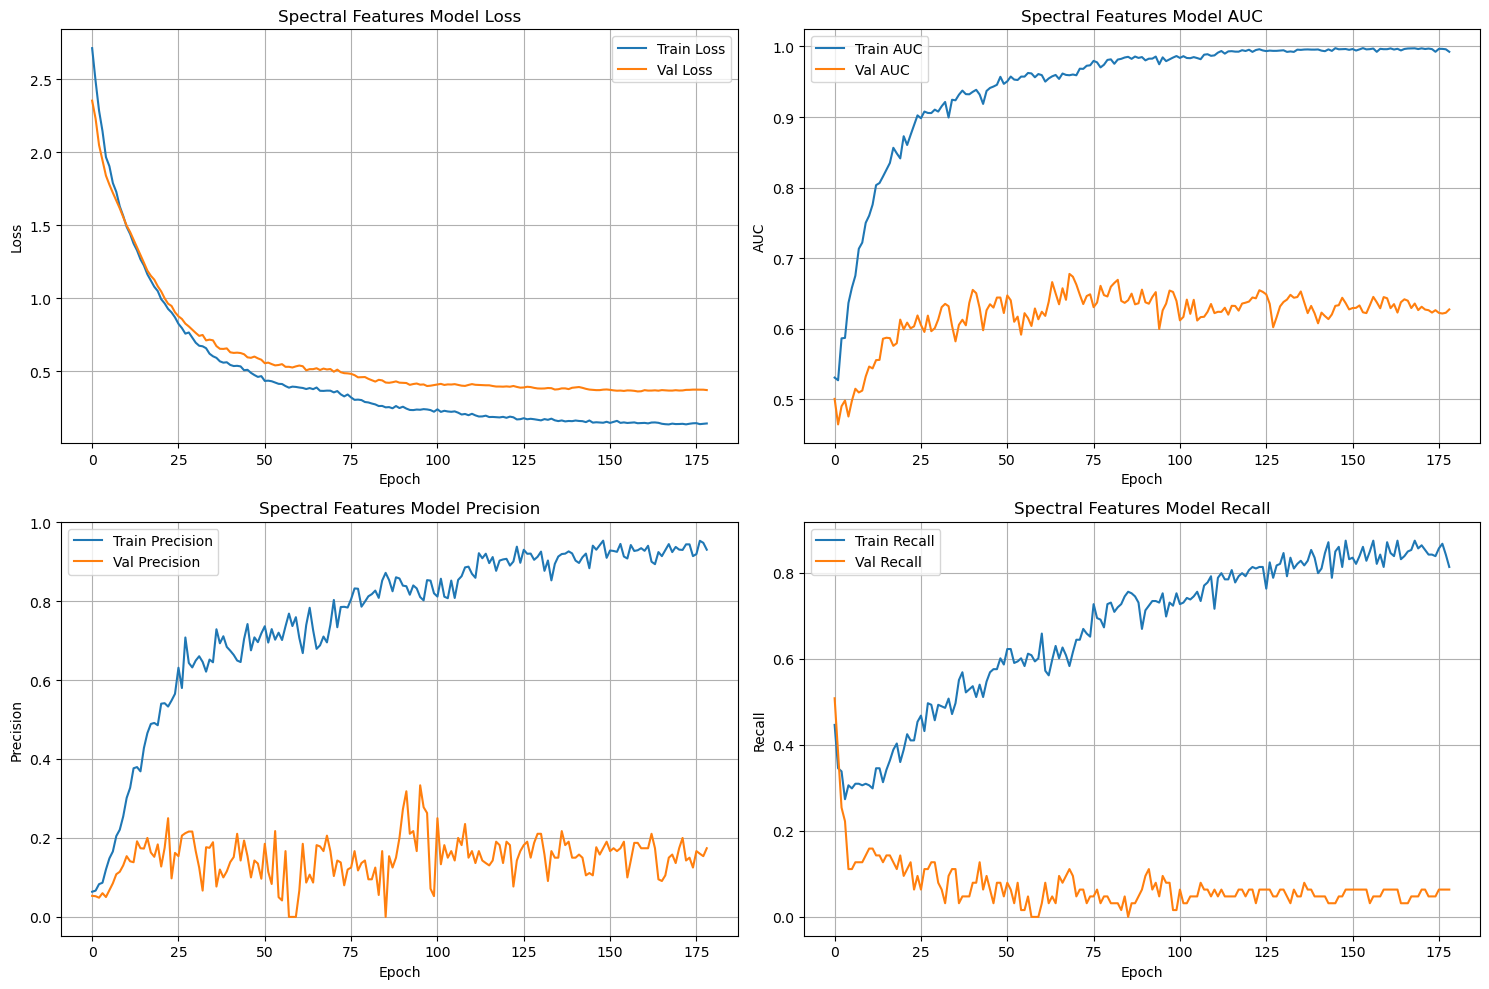


EVALUATION

Validation Results (Spectral Features Only):
Loss: 0.3611
Accuracy: 0.0308
AUC: 0.6289
Precision: 0.1875
Recall: 0.0476

GENERATING PREDICTIONS
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Creating submission file...
Submission saved to: Submission/nn_bird_spectral_only_auc0.6289.csv

SPECTRAL FEATURES MODEL TRAINING COMPLETE!
Best model saved to: models/best_bird_model_spectral_only.h5
Training history saved to: log/training_history_spectral_only.pkl
Submission file: Submission/nn_bird_spectral_only_auc0.6289.csv
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Creating submission file...
Submission saved to: Submission/nn_bird_spectral_only_auc0.6289.csv

SPECTRAL FEATURES MODEL TRAINING COMPLETE!
Best model saved to: models/best_bird_model_spectral_only.h5
Training history saved to: log/training_history_spectral_only.pkl
Submission file: Submission/nn_bird_spectral_only_auc0.6289.csv


In [12]:
###################################################
# SPECTRAL FEATURES ONLY NEURAL NETWORK
# Uses only spectral features from PKL files (TRAIN_SPEC_FEATURES_freq5.pkl)
###################################################

# Import required libraries if not already imported
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tqdm import tqdm

print("="*60)
print("SPECTRAL FEATURES ONLY NEURAL NETWORK FOR BIRD CLASSIFICATION")
print("="*60)

# Load spectral features directly from PKL files
print("\nLoading spectral features from PKL files...")

# TRAIN data - spectral features
pkl_file = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'rb')
X_train_spec = pickle.load(pkl_file)
pkl_file.close()

# TEST data - spectral features  
pkl_file = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'rb')
X_test_spec = pickle.load(pkl_file)
pkl_file.close()

# Get labels from label dataframe (fold 0 = training set)
train_mask = label['fold'] == 0
test_mask = label['fold'] == 1
y_train_spec = label[train_mask][range(num_species)].values
y_test_spec = label[test_mask][range(num_species)].values

print(f"\nDataset shapes (Spectral Features Only):")
print(f"Training features: {X_train_spec.shape}")
print(f"Training labels: {y_train_spec.shape}")
print(f"Test features: {X_test_spec.shape}")
print(f"Test labels: {y_test_spec.shape}")

# Feature scaling
scaler_spec = StandardScaler()
X_train_spec_scaled = scaler_spec.fit_transform(X_train_spec)
X_test_spec_scaled = scaler_spec.transform(X_test_spec)

# Split training data for validation
X_train_spec_nn, X_val_spec_nn, y_train_spec_nn, y_val_spec_nn = train_test_split(
    X_train_spec_scaled, y_train_spec, test_size=0.2, random_state=42
)

print(f"\nAfter train/validation split:")
print(f"Training: {X_train_spec_nn.shape}, Validation: {X_val_spec_nn.shape}")

# Calculate class weights
n_pos_spec = np.sum(y_train_spec_nn)
n_neg_spec = np.size(y_train_spec_nn) - n_pos_spec
total_spec = np.size(y_train_spec_nn)

weight_for_0_spec = (1 / n_neg_spec) * (total_spec / 2.0)
weight_for_1_spec = (1 / n_pos_spec) * (total_spec / 2.0)

class_weight_spec = {0: weight_for_0_spec, 1: weight_for_1_spec}

print(f"\nClass weights:")
print(f"Weight for class 0 (no bird): {weight_for_0_spec:.2f}")
print(f"Weight for class 1 (bird present): {weight_for_1_spec:.2f}")

# Build Spectral Features Neural Network
def create_spectral_bird_classifier(input_dim, num_classes):
    """
    Creates a neural network for bird classification using only spectral features
    """
    model = keras.Sequential([
        # Input layer
        layers.Dense(512, input_shape=(input_dim,),
                     kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LeakyReLU(alpha=0.1),
        
        layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),               
        layers.Dropout(0.3),

        layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),                
        layers.Dropout(0.25),
        
        layers.Dense(64, kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.2),
        
        layers.Flatten(),
        # Output layer - sigmoid for multi-label classification
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model

# Create spectral features model
model_spec = create_spectral_bird_classifier(X_train_spec_scaled.shape[1], num_species)

# Compile model
model_spec.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # For multi-label classification
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Model summary
print("\n" + "="*60)
print("SPECTRAL FEATURES MODEL ARCHITECTURE")
print("="*60)
model_spec.summary()

# Callbacks
early_stopping_spec = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_spec = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint_spec = callbacks.ModelCheckpoint(
    model_folder + 'best_bird_model_spectral_only.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Custom callback for progress bar
class TqdmCallbackSpec(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.pbar = tqdm(total=self.epochs, desc='Training (Spectral Features Only)')
    
    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'auc': f"{logs['auc']:.4f}",
            'val_auc': f"{logs['val_auc']:.4f}"
        })
    
    def on_train_end(self, logs=None):
        self.pbar.close()

tqdm_callback_spec = TqdmCallbackSpec()

# Train the spectral features model
print("\n" + "="*60)
print("TRAINING SPECTRAL FEATURES MODEL")
print("="*60)

history_spec = model_spec.fit(
    X_train_spec_nn, y_train_spec_nn,
    validation_data=(X_val_spec_nn, y_val_spec_nn),
    epochs=500,
    batch_size=16,
    callbacks=[early_stopping_spec, reduce_lr_spec, model_checkpoint_spec, tqdm_callback_spec],
    verbose=0,
    class_weight=class_weight_spec
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history_spec.history['loss'], label='Train Loss')
axes[0, 0].plot(history_spec.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Spectral Features Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history_spec.history['auc'], label='Train AUC')
axes[0, 1].plot(history_spec.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('Spectral Features Model AUC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history_spec.history['precision'], label='Train Precision')
axes[1, 0].plot(history_spec.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Spectral Features Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history_spec.history['recall'], label='Train Recall')
axes[1, 1].plot(history_spec.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Spectral Features Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(log_folder + 'training_history_spectral_only.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Evaluate on validation set
val_results_spec = model_spec.evaluate(X_val_spec_nn, y_val_spec_nn, verbose=0)
print(f"\nValidation Results (Spectral Features Only):")
print(f"Loss: {val_results_spec[0]:.4f}")
print(f"Accuracy: {val_results_spec[1]:.4f}")
print(f"AUC: {val_results_spec[2]:.4f}")
print(f"Precision: {val_results_spec[3]:.4f}")
print(f"Recall: {val_results_spec[4]:.4f}")

# Make predictions on test set
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

test_predictions_spec = model_spec.predict(X_test_spec_scaled, batch_size=32, verbose=1)

# Create submission file
print("\nCreating submission file...")
Submission_ID_spec = []
Submission_PROB_spec = []

# Get test rec_ids from label dataframe
test_rec_ids = label[label['fold'] == 1]['rec_id'].values

for bird in range(num_species):
    ids = test_rec_ids * 100 + bird
    probs = test_predictions_spec[:, bird]
    Submission_ID_spec.extend(list(ids))
    Submission_PROB_spec.extend(list(probs))

SubmissionDf_spec = pd.DataFrame({
    'Id': Submission_ID_spec,
    'Probability': Submission_PROB_spec
})

submission_filename_spec = subm_folder + f'nn_bird_spectral_only_auc{val_results_spec[2]:.4f}.csv'
SubmissionDf_spec.to_csv(submission_filename_spec, index=False)
print(f"Submission saved to: {submission_filename_spec}")

# Save training history
history_dict_spec = {
    'loss': history_spec.history['loss'],
    'val_loss': history_spec.history['val_loss'],
    'auc': history_spec.history['auc'],
    'val_auc': history_spec.history['val_auc'],
    'precision': history_spec.history['precision'],
    'val_precision': history_spec.history['val_precision'],
    'recall': history_spec.history['recall'],
    'val_recall': history_spec.history['val_recall']
}

with open(log_folder + 'training_history_spectral_only.pkl', 'wb') as f:
    pickle.dump(history_dict_spec, f)

print("\n" + "="*60)
print("SPECTRAL FEATURES MODEL TRAINING COMPLETE!")
print("="*60)
print(f"Best model saved to: {model_folder}best_bird_model_spectral_only.h5")
print(f"Training history saved to: {log_folder}training_history_spectral_only.pkl")
print(f"Submission file: {submission_filename_spec}")

# Improved Neural Network - All Features
Train an improved neural network using ALL features (spectral + segments + log spectral + pc) with advanced architecture

IMPROVED NEURAL NETWORK WITH ALL FEATURES

Combining all features...

Dataset shapes (All Features):
Training features: (322, 6079)
Training labels: (322, 19)
Test features: (323, 6079)

After train/validation split:
Training: (289, 6079), Validation: (33, 6079)

Class weights:
Weight for class 0 (no bird): 0.53
Weight for class 1 (bird present): 8.89

IMPROVED MODEL ARCHITECTURE (ALL FEATURES)

IMPROVED MODEL ARCHITECTURE (ALL FEATURES)


/home/crabbedfish/anaconda3/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6079)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 6079)           │        24,316 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1052)           │     6,396,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 1052)           │         4,208 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_69 (LeakyReLU)      │ (None, 1052)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 1052)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1024)           │     1,078,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_70 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 768)            │       787,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_71 (LeakyReLU)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_72 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 384)            │       196,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_73 (LeakyReLU)      │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 384)            │             

 Total params: 9,034,367 (34.46 MB)

...

Training (Improved - All Features):  29%|██▉       | 145/500 [04:37<10:55,  1.85s/it, loss=1.9792, val_loss=1.9494, auc=0.8883, val_auc=0.8167]


Epoch 146: val_auc did not improve from 0.81946


Training (Improved - All Features):  29%|██▉       | 146/500 [04:39<11:01,  1.87s/it, loss=1.9599, val_loss=1.9495, auc=0.8720, val_auc=0.8168]

Epoch 146: early stopping
Restoring model weights from the end of the best epoch: 121.
Restoring model weights from the end of the best epoch: 121.


Training (Improved - All Features):  29%|██▉       | 146/500 [04:39<11:16,  1.91s/it, loss=1.9599, val_loss=1.9495, auc=0.8720, val_auc=0.8168]



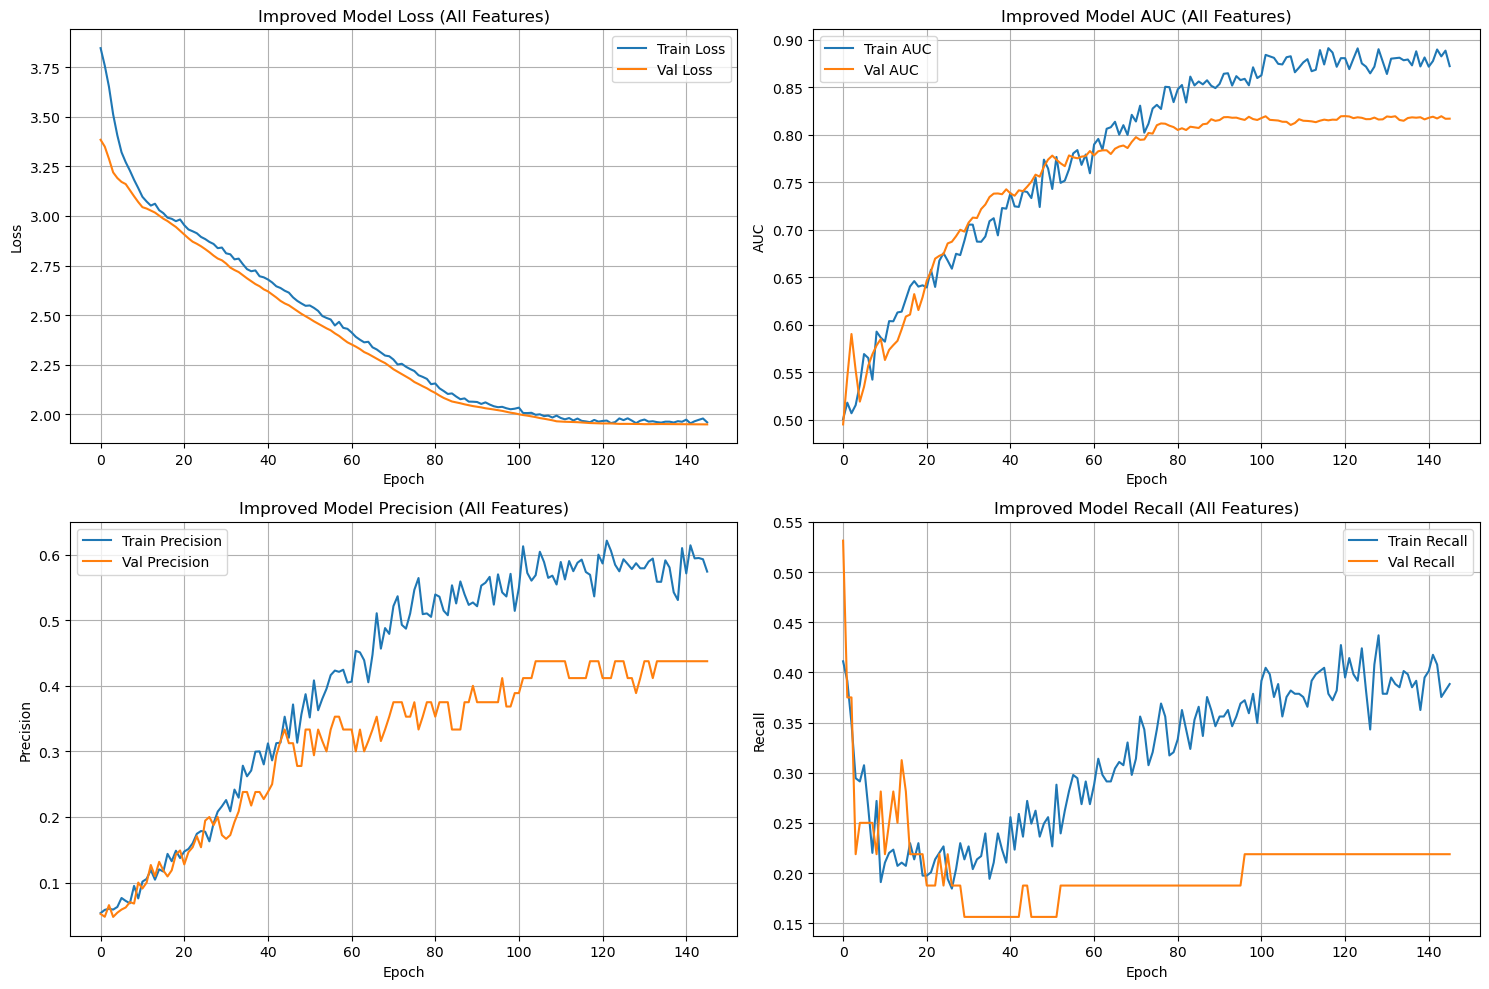


EVALUATION

Validation Results (Improved - All Features):
Loss: 1.9542
Accuracy: 0.0909
AUC: 0.8195
Precision: 0.4118
Recall: 0.2188

GENERATING PREDICTIONS
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Creating submission file...
Submission saved to: Submission/nn_bird_improved_all_features_auc0.8195.csv

IMPROVED MODEL TRAINING COMPLETE!
Best model saved to: models/best_bird_model_improved_all_features.h5
Training history saved to: log/training_history_improved_all_features.pkl
Submission file: Submission/nn_bird_improved_all_features_auc0.8195.csv

🎯 Final Validation AUC: 0.8195

Creating submission file...
Submission saved to: Submission/nn_bird_improved_all_features_auc0.8195.csv

IMPROVED MODEL TRAINING COMPLETE!
Best model saved to: models/best_bird_model_improved_all_features.h5
Training history saved to: log/training_history_improved_all_features.pkl
Submission file: Submission/nn_bird_improved_all_features_auc0.8195.csv

🎯 Final Validation 

In [23]:
###################################################
# IMPROVED NEURAL NETWORK - ALL FEATURES
# Uses all available features with advanced architecture
###################################################

# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, models
from tqdm import tqdm

print("="*60)
print("IMPROVED NEURAL NETWORK WITH ALL FEATURES")
print("="*60)

# Create folders if they don't exist
os.makedirs(model_folder, exist_ok=True)
os.makedirs(log_folder, exist_ok=True)

# Read histogram of segments features
hos = pd.read_csv(supplemental_folder + 'histogram_of_segments.txt', sep=',', skiprows=1, header=0)
hos_features = ['hos_'+str(x) for x in range(100)]
hos.columns = ['rec_id'] + hos_features

data = pd.merge(left=label, right=hos, how='left', left_on='rec_id', right_on='rec_id')
data = data.fillna(0)

# TRAIN data
train_data = data[data.fold == 0]
pc_train = []
for i in range(len(train_data)):
    s = train_data.filename.iloc[i][:5]
    pc_train.append(int(s[2:s.find('_')]))
train_data = train_data.copy()
train_data['pc'] = pc_train

# Load spectral features
pkl_file = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'rb')
tr_spec = pickle.load(pkl_file)
pkl_file.close()
spec_names = ['tr_spec_'+str(x) for x in range(tr_spec.shape[1])]

# Load logarithmic spectral features
pkl_file = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
tr_log_spec = pickle.load(pkl_file)
pkl_file.close()
log_spec_names = ['tr_log_spec_'+str(x) for x in range(tr_log_spec.shape[1])]

# TEST data
test_data = data[data.fold == 1]
pc_test = []
for i in range(len(test_data)):
    s = test_data.filename.iloc[i][:5]
    pc_test.append(int(s[2:s.find('_')]))
test_data = test_data.copy()
test_data['pc'] = pc_test

# Load test spectral features
pkl_file = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'rb')
test_spec = pickle.load(pkl_file)
pkl_file.close()

# Load test logarithmic features
pkl_file = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
test_log_spec = pickle.load(pkl_file)
pkl_file.close()

# Combine all features
print("\nCombining all features...")
X_train_all = np.concatenate([
    tr_spec,
    tr_log_spec,
    train_data[hos_features].values,
    train_data[['pc']].values
], axis=1)

X_test_all = np.concatenate([
    test_spec,
    test_log_spec,
    test_data[hos_features].values,
    test_data[['pc']].values
], axis=1)

y_train_all = train_data[range(num_species)].values

print(f"\nDataset shapes (All Features):")
print(f"Training features: {X_train_all.shape}")
print(f"Training labels: {y_train_all.shape}")
print(f"Test features: {X_test_all.shape}")

# Feature scaling
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

# Split training data for validation
X_train_all_nn, X_val_all_nn, y_train_all_nn, y_val_all_nn = train_test_split(
    X_train_all_scaled, y_train_all, train_size=0.90, random_state=42
)

print(f"\nAfter train/validation split:")
print(f"Training: {X_train_all_nn.shape}, Validation: {X_val_all_nn.shape}")

# Calculate class weights
n_pos_all = np.sum(y_train_all_nn)
n_neg_all = np.size(y_train_all_nn) - n_pos_all
total_all = np.size(y_train_all_nn)

weight_for_0_all = (1 / n_neg_all) * (total_all / 2.0)
weight_for_1_all = (1 / n_pos_all) * (total_all / 2.0)

class_weight_all = {0: weight_for_0_all, 1: weight_for_1_all}

print(f"\nClass weights:")
print(f"Weight for class 0 (no bird): {weight_for_0_all:.2f}")
print(f"Weight for class 1 (bird present): {weight_for_1_all:.2f}")

# Build Improved Neural Network with Residual-like connections
def create_improved_bird_classifier(input_dim, num_classes):
    """
    Creates an improved deep neural network with:
    - Deeper architecture
    - Batch Normalization for stable training
    - Dropout for regularization
    - LeakyReLU activation
    - Dense connections
    """
    inputs = keras.Input(shape=(input_dim,))
    
    x = layers.BatchNormalization()(inputs)

    x = layers.Dense(1052, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.45)(x)
    
    # First block - 1024 neurons
    x = layers.Dense(1024, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)
    
    # Second block - 768 neurons
    x = layers.Dense(768, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.35)(x)
    
    # Third block - 512 neurons
    x = layers.Dense(512, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.3)(x)
    
    # Fourth block - 384 neurons
    x = layers.Dense(384, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.25)(x)
    
    # Fifth block - 256 neurons
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.25)(x)
    
    # Sixth block - 128 neurons
    x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.2)(x)
    
    # Seventh block - 64 neurons
    x = layers.Dense(64, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.15)(x)
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create improved model
model_improved = create_improved_bird_classifier(X_train_all_scaled.shape[1], num_species)

# Compile model with different optimizer settings
model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Lower learning rate
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Model summary
print("\n" + "="*60)
print("IMPROVED MODEL ARCHITECTURE (ALL FEATURES)")
print("="*60)
model_improved.summary()

# Callbacks
early_stopping_all = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=25,
    restore_best_weights=True,
    mode='max',
    verbose=1,
)

reduce_lr_all = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.3,
    patience=8,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

model_checkpoint_all = callbacks.ModelCheckpoint(
    model_folder + 'best_bird_model_improved_all_features.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Custom callback for progress bar
class TqdmCallbackImproved(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.pbar = tqdm(total=self.epochs, desc='Training (Improved - All Features)')
    
    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'auc': f"{logs['auc']:.4f}",
            'val_auc': f"{logs['val_auc']:.4f}"
        })
    
    def on_train_end(self, logs=None):
        self.pbar.close()

tqdm_callback_improved = TqdmCallbackImproved()

# Train the improved model
print("\n" + "="*60)
print("TRAINING IMPROVED MODEL WITH ALL FEATURES")
print("="*60)

history_improved = model_improved.fit(
    X_train_all_nn, y_train_all_nn,
    validation_data=(X_val_all_nn, y_val_all_nn),
    epochs=500,
    batch_size=16,
    callbacks=[early_stopping_all, reduce_lr_all, model_checkpoint_all, tqdm_callback_improved],
    verbose=0,
    class_weight=class_weight_all
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history_improved.history['loss'], label='Train Loss')
axes[0, 0].plot(history_improved.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Improved Model Loss (All Features)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history_improved.history['auc'], label='Train AUC')
axes[0, 1].plot(history_improved.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('Improved Model AUC (All Features)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history_improved.history['precision'], label='Train Precision')
axes[1, 0].plot(history_improved.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Improved Model Precision (All Features)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history_improved.history['recall'], label='Train Recall')
axes[1, 1].plot(history_improved.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Improved Model Recall (All Features)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(log_folder + 'training_history_improved_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Evaluate on validation set
val_results_improved = model_improved.evaluate(X_val_all_nn, y_val_all_nn, verbose=0)
print(f"\nValidation Results (Improved - All Features):")
print(f"Loss: {val_results_improved[0]:.4f}")
print(f"Accuracy: {val_results_improved[1]:.4f}")
print(f"AUC: {val_results_improved[2]:.4f}")
print(f"Precision: {val_results_improved[3]:.4f}")
print(f"Recall: {val_results_improved[4]:.4f}")

# Make predictions on test set
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

test_predictions_improved = model_improved.predict(X_test_all_scaled, batch_size=32, verbose=1)

# Create submission file
print("\nCreating submission file...")
Submission_ID_improved = []
Submission_PROB_improved = []

# Get test rec_ids
test_rec_ids_all = test_data['rec_id'].values

for bird in range(num_species):
    ids = test_rec_ids_all * 100 + bird
    probs = test_predictions_improved[:, bird]
    Submission_ID_improved.extend(list(ids))
    Submission_PROB_improved.extend(list(probs))

SubmissionDf_improved = pd.DataFrame({
    'Id': Submission_ID_improved,
    'Probability': Submission_PROB_improved
})

submission_filename_improved = subm_folder + f'nn_bird_improved_all_features_auc{val_results_improved[2]:.4f}.csv'
SubmissionDf_improved.to_csv(submission_filename_improved, index=False)
print(f"Submission saved to: {submission_filename_improved}")

# Save training history
history_dict_improved = {
    'loss': history_improved.history['loss'],
    'val_loss': history_improved.history['val_loss'],
    'auc': history_improved.history['auc'],
    'val_auc': history_improved.history['val_auc'],
    'precision': history_improved.history['precision'],
    'val_precision': history_improved.history['val_precision'],
    'recall': history_improved.history['recall'],
    'val_recall': history_improved.history['val_recall']
}

with open(log_folder + 'training_history_improved_all_features.pkl', 'wb') as f:
    pickle.dump(history_dict_improved, f)

print("\n" + "="*60)
print("IMPROVED MODEL TRAINING COMPLETE!")
print("="*60)
print(f"Best model saved to: {model_folder}best_bird_model_improved_all_features.h5")
print(f"Training history saved to: {log_folder}training_history_improved_all_features.pkl")
print(f"Submission file: {submission_filename_improved}")
print(f"\n🎯 Final Validation AUC: {val_results_improved[2]:.4f}")